In [87]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [89]:
df = pd.read_csv('heart_disease_uci.csv')

In [90]:
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [91]:
df['trestbps'].mean()

np.float64(132.13240418118468)

In [92]:
df['trestbps'].max()

200.0

In [93]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [94]:
df['num'].max()

4

In [95]:
df['num'].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [96]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
915    False
916    False
917    False
918    False
919    False
Length: 920, dtype: bool

In [97]:
#retourne toutes les valeurs distinctes présentes dans chaque colonne du dataframe.
for col in df.columns:
    print(col)
    print(df[col].unique())
    print('-------------')

id
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242 243 244 245 246

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [99]:
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,920.0,NaN,NaN,NaN,460.5,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,NaN,NaN,NaN,53.51087,9.424685,28.0,47.0,54.0,60.0,77.0
sex,920,2,Male,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dataset,920,4,Cleveland,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cp,920,4,asymptomatic,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trestbps,861.0,NaN,NaN,NaN,132.132404,19.06607,0.0,120.0,130.0,140.0,200.0
chol,890.0,NaN,NaN,NaN,199.130337,110.78081,0.0,175.0,223.0,268.0,603.0
fbs,830,2,False,692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restecg,918,3,normal,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thalch,865.0,NaN,NaN,NaN,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0


In [100]:
df['target']=(df['num']>0).astype(int)

In [101]:
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2,1
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0,0


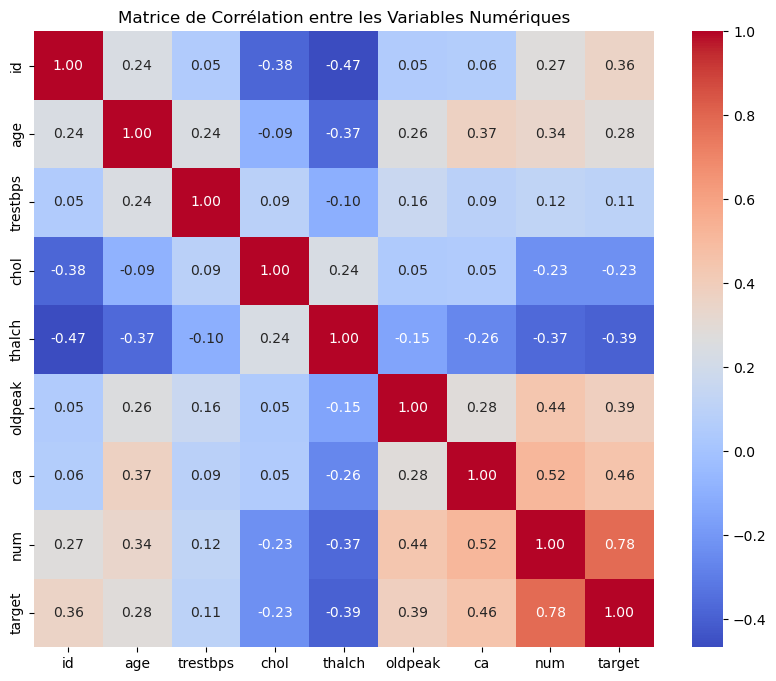

In [102]:
numeric_columns = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_columns.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title("Matrice de Corrélation entre les Variables Numériques")
plt.show()

# Missing Values

## ------------trestbps

In [103]:
df['trestbps']=df['trestbps'].replace(0,np.nan)

In [104]:
(df['trestbps']==0).sum()

np.int64(0)

In [105]:
df['trestbps'].fillna(df['trestbps'].median() , inplace=True)

In [106]:
df['trestbps'].isnull().sum()

np.int64(0)

In [107]:
df['trestbps'].min()

80.0

## -------------Chol

In [108]:
df['chol'].isnull().sum()

np.int64(30)

In [109]:
(df['chol']==0).sum()

np.int64(172)

In [110]:
df['chol']=df['chol'].replace(0,np.nan)

In [111]:
df['chol'].fillna(df['chol'].median() , inplace=True)

In [112]:
df['chol'].isnull().sum()

np.int64(0)

## ------------thalch

In [113]:
df['thalch'].isnull().sum()

np.int64(55)

In [114]:
(df['thalch']==0).sum()

np.int64(0)

In [115]:
df['thalch'].fillna(df['thalch'].median() , inplace=True)

## ------------ca

In [116]:
df['ca_missing'] = df['ca'].isnull().astype(int)
df['ca'] = df['ca'].fillna(-1)

In [117]:
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target,ca_missing
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1,0
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1,0
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,-1.0,NaN,1,1,1
916,917,62,Male,VA Long Beach,typical angina,130.0,139.0,False,st-t abnormality,140.0,NaN,NaN,NaN,-1.0,NaN,0,0,1
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,-1.0,fixed defect,2,1,1
918,919,58,Male,VA Long Beach,asymptomatic,130.0,385.0,True,lv hypertrophy,140.0,NaN,NaN,NaN,-1.0,NaN,0,0,1


## -----------thal

In [118]:
df['thal'] = df['thal'].fillna('Unknown')

In [119]:
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target,ca_missing
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1,0
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1,0
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,-1.0,Unknown,1,1,1
916,917,62,Male,VA Long Beach,typical angina,130.0,139.0,False,st-t abnormality,140.0,NaN,NaN,NaN,-1.0,Unknown,0,0,1
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,-1.0,fixed defect,2,1,1
918,919,58,Male,VA Long Beach,asymptomatic,130.0,385.0,True,lv hypertrophy,140.0,NaN,NaN,NaN,-1.0,Unknown,0,0,1


## --------------fbs

In [120]:
df['fbs'] = df['fbs'].map({False: 0, True: 1})

In [121]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

cols = [
    'age',
    'trestbps',
    'chol',
    'thalch',
    'oldpeak',
    'fbs'
]

df[cols] = imputer.fit_transform(df[cols])

In [122]:
df['fbs'].isnull().sum()

np.int64(0)

## -------------slope

In [123]:
df.groupby('target')['slope'].value_counts(dropna=False)

target  slope      
0       NaN            193
        upsloping      125
        flat            79
        downsloping     14
1       flat           266
        NaN            116
        upsloping       78
        downsloping     49
Name: count, dtype: int64

In [124]:
df['slope'] = df['slope'].fillna('Unknown')

In [125]:
df['slope'].isnull().sum()

np.int64(0)

In [126]:
print(df['slope'].unique())

['downsloping' 'flat' 'upsloping' 'Unknown']


In [127]:
df=pd.get_dummies(df, columns=['slope'], drop_first=False )

In [128]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [129]:
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,...,oldpeak,ca,thal,num,target,ca_missing,slope_Unknown,slope_downsloping,slope_flat,slope_upsloping
0,1,63.0,Male,Cleveland,typical angina,145.0,233.0,1.0,lv hypertrophy,150.0,...,2.30,0.0,fixed defect,0,0,0,0,1,0,0
1,2,67.0,Male,Cleveland,asymptomatic,160.0,286.0,0.0,lv hypertrophy,108.0,...,1.50,3.0,normal,2,1,0,0,0,1,0
2,3,67.0,Male,Cleveland,asymptomatic,120.0,229.0,0.0,lv hypertrophy,129.0,...,2.60,2.0,reversable defect,1,1,0,0,0,1,0
3,4,37.0,Male,Cleveland,non-anginal,130.0,250.0,0.0,normal,187.0,...,3.50,0.0,normal,0,0,0,0,1,0,0
4,5,41.0,Female,Cleveland,atypical angina,130.0,204.0,0.0,lv hypertrophy,172.0,...,1.40,0.0,normal,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54.0,Female,VA Long Beach,asymptomatic,127.0,333.0,1.0,st-t abnormality,154.0,...,0.00,-1.0,Unknown,1,1,1,1,0,0,0
916,917,62.0,Male,VA Long Beach,typical angina,130.0,139.0,0.0,st-t abnormality,140.0,...,1.12,-1.0,Unknown,0,0,1,1,0,0,0
917,918,55.0,Male,VA Long Beach,asymptomatic,122.0,223.0,1.0,st-t abnormality,100.0,...,0.00,-1.0,fixed defect,2,1,1,1,0,0,0
918,919,58.0,Male,VA Long Beach,asymptomatic,130.0,385.0,1.0,lv hypertrophy,140.0,...,1.22,-1.0,Unknown,0,0,1,1,0,0,0


## ------------oldpeak

In [130]:
df['oldpeak'].describe()

count    920.000000
mean       0.901109
std        1.065806
min       -2.600000
25%        0.000000
50%        0.600000
75%        1.500000
max        6.200000
Name: oldpeak, dtype: float64

In [131]:
import seaborn as sns
sns.histplot(df['oldpeak'], kde=True)

<Axes: xlabel='oldpeak', ylabel='Count'>

In [132]:
df[df['oldpeak'] < 0]['oldpeak'].value_counts()

oldpeak
-0.5    2
-1.0    2
-1.1    1
-0.1    1
-1.5    1
-2.6    1
-0.7    1
-2.0    1
-0.2    1
-0.8    1
-0.9    1
Name: count, dtype: int64

In [133]:
import numpy as np

df.loc[df['oldpeak'] < 0, 'oldpeak'] = np.nan
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())

In [134]:
df['oldpeak'].isnull().sum()

np.int64(0)

## ---------------exang

In [135]:
df.groupby('target')['exang'].value_counts(dropna=False)

target  exang
0       False    336
        True      55
        NaN       20
1       True     282
        False    192
        NaN       35
Name: count, dtype: int64

In [136]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')
df[['exang']] = imputer.fit_transform(df[['exang']])

df['exang'] = df['exang'].astype(int)

In [137]:
df['exang']

0      0
1      1
2      1
3      0
4      0
      ..
915    0
916    0
917    0
918    0
919    1
Name: exang, Length: 920, dtype: int64

In [138]:
df['exang'].isnull().sum()

np.int64(0)

## --------------restecg

In [139]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')
df[['restecg']] = imputer.fit_transform(df[['restecg']])

In [140]:
df['exang'].isnull().sum()

np.int64(0)

# Encoding

In [141]:
df['sex'] = df['sex'].map({'Male':1, 'Female':0})

df = pd.get_dummies(
    df,
    columns=['cp', 'restecg', 'thal'],
    drop_first=False,
    dtype=int
)

In [142]:
df.drop(['id', 'num', 'dataset'], axis=1, inplace=True, errors='ignore')

In [143]:
df

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca,target,...,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,thal_Unknown,thal_fixed defect,thal_normal,thal_reversable defect
0,63.0,1,145.0,233.0,1.0,150.0,0,2.30,0.0,0,...,0,0,1,1,0,0,0,1,0,0
1,67.0,1,160.0,286.0,0.0,108.0,1,1.50,3.0,1,...,0,0,0,1,0,0,0,0,1,0
2,67.0,1,120.0,229.0,0.0,129.0,1,2.60,2.0,1,...,0,0,0,1,0,0,0,0,0,1
3,37.0,1,130.0,250.0,0.0,187.0,0,3.50,0.0,0,...,0,1,0,0,1,0,0,0,1,0
4,41.0,0,130.0,204.0,0.0,172.0,0,1.40,0.0,0,...,1,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54.0,0,127.0,333.0,1.0,154.0,0,0.00,-1.0,1,...,0,0,0,0,0,1,1,0,0,0
916,62.0,1,130.0,139.0,0.0,140.0,0,1.12,-1.0,0,...,0,0,1,0,0,1,1,0,0,0
917,55.0,1,122.0,223.0,1.0,100.0,0,0.00,-1.0,1,...,0,0,0,0,0,1,0,1,0,0
918,58.0,1,130.0,385.0,1.0,140.0,0,1.22,-1.0,0,...,0,0,0,1,0,0,1,0,0,0


# outliers

In [144]:
numeric_columns = df.select_dtypes(include=['int64', 'float64'])

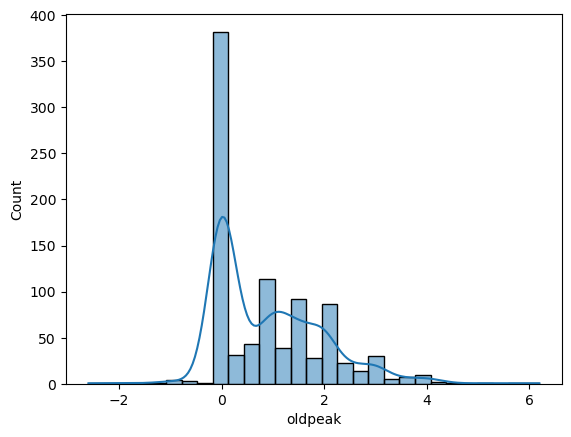

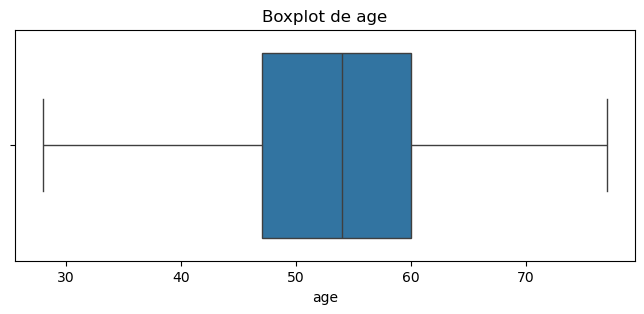

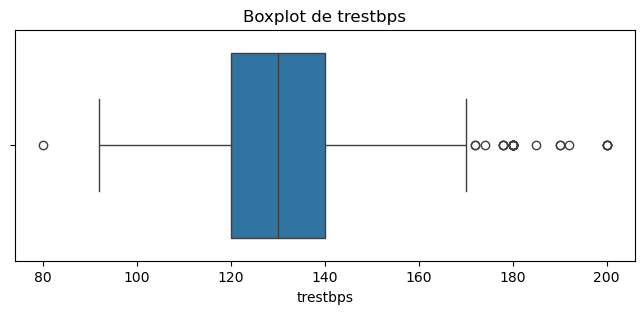

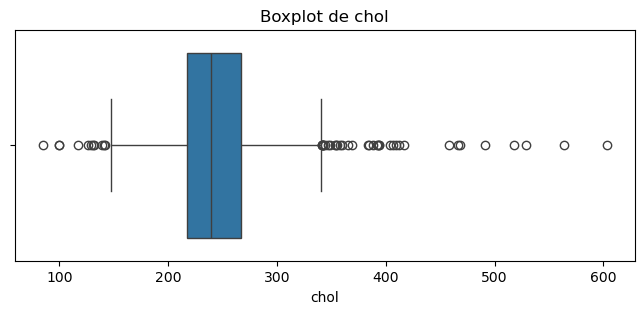

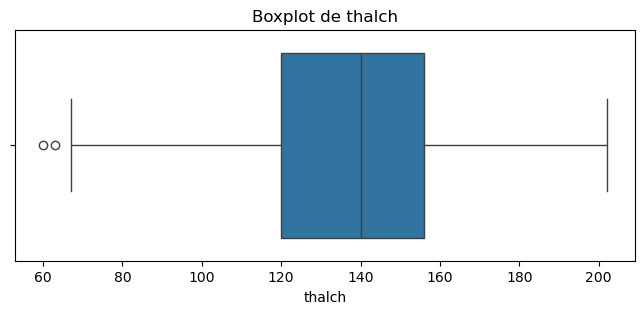

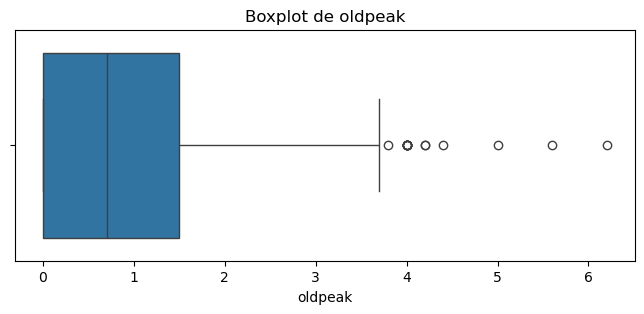

In [145]:

continuous_cols = [
    'age',
    'trestbps',
    'chol',
    'thalch',
    'oldpeak'
]

for col in continuous_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.show()
    plt.close()

In [146]:
continuous_cols = [
    'age',
    'trestbps',
    'chol',
    'thalch',
    'oldpeak'
]

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {n_outliers}")

age: 0
trestbps: 27
chol: 47
thalch: 2
oldpeak: 15


# Train/Test Split

In [147]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# SMOTE and ADASYN

## SMOTE

In [148]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

## ADASYN

In [149]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)

X_train_adasyn, y_train_adasyn = adasyn.fit_resample(
    X_train,
    y_train
)

# Scaling

## Original

In [150]:
from imblearn.over_sampling import ADASYN
from sklearn.preprocessing import StandardScaler

scaler_original = StandardScaler()

X_train_original = scaler_original.fit_transform(X_train)
X_test_original = scaler_original.transform(X_test)

## Smote

In [151]:
scaler_smote = StandardScaler()

X_train_smote = scaler_smote.fit_transform(X_train_smote)
X_test_smote = scaler_smote.transform(X_test)

## Adansy

In [152]:
scaler_adasyn = StandardScaler()

X_train_adasyn = scaler_adasyn.fit_transform(X_train_adasyn)
X_test_adasyn = scaler_adasyn.transform(X_test)

# DeepSmote

In [153]:
scaler_deepsmote = StandardScaler()

X_train_scaled = scaler_deepsmote.fit_transform(X_train)
X_test_scaled = scaler_deepsmote.transform(X_test)

In [154]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, BatchNormalization
from tensorflow.keras.models import Model

In [155]:
input_dim = X_train_scaled.shape[1]

input_layer = Input(shape=(input_dim,))

x = Dense(128, activation="relu")(input_layer)
x = BatchNormalization()(x)

x = Dense(64, activation="relu")(x)
x = BatchNormalization()(x)

latent = Dense(32, activation="relu", name="latent_space")(x)

In [156]:
x = Dense(64, activation="relu")(latent)
x = BatchNormalization()(x)

x = Dense(128, activation="relu")(x)
x = BatchNormalization()(x)

output_layer = Dense(input_dim, activation="linear")(x)

In [157]:
autoencoder = Model(input_layer, output_layer)

encoder = Model(input_layer, latent)

In [158]:
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

In [159]:
history = autoencoder.fit(
    X_train_scaled,
    X_train_scaled,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 1.8612 - val_loss: 0.9726
Epoch 2/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9026 - val_loss: 0.9297
Epoch 3/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6443 - val_loss: 0.8896
Epoch 4/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5214 - val_loss: 0.8496
Epoch 5/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4489 - val_loss: 0.8075
Epoch 6/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3999 - val_loss: 0.7640
Epoch 7/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3627 - val_loss: 0.7209
Epoch 8/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3334 - val_loss: 0.6764
Epoch 9/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3092 - val_loss: 0.6352
Epoch 10/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2872 - val_loss: 0.5951
Epoch 11/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2694 - val_loss: 0.5601
Epoch 12/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.

In [160]:
X_train_latent = encoder.predict(X_train_scaled)

print(X_train_latent.shape)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
(736, 32)


In [161]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_latent_smote, y_latent_smote = smote.fit_resample(
    X_train_latent,
    y_train
)

In [162]:
print(X_latent_smote.shape)
print(y_latent_smote.shape)

(814, 32)
(814,)


In [163]:
from tensorflow.keras.models import Model

latent_input = Input(shape=(32,))

decoder_layers = autoencoder.layers[-5](latent_input)
decoder_layers = autoencoder.layers[-4](decoder_layers)
decoder_layers = autoencoder.layers[-3](decoder_layers)
decoder_layers = autoencoder.layers[-2](decoder_layers)
decoder_output = autoencoder.layers[-1](decoder_layers)

decoder = Model(latent_input, decoder_output)

In [164]:
X_train_deepsmote = decoder.predict(X_latent_smote)

print(X_train_deepsmote.shape)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
(814, 25)


# Focal Loss

In [177]:
import tensorflow as tf

def focal_loss(alpha=0.25, gamma=2.0):

    def loss(y_true, y_pred):

        y_true = tf.cast(y_true, tf.float32)

        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0-epsilon)

        bce = -(y_true*tf.math.log(y_pred) +
                (1-y_true)*tf.math.log(1-y_pred))

        p_t = y_true*y_pred + (1-y_true)*(1-y_pred)

        alpha_factor = y_true*alpha + (1-y_true)*(1-alpha)

        modulating_factor = tf.pow(1-p_t, gamma)

        return tf.reduce_mean(alpha_factor * modulating_factor * bce)

    return loss

# Deep MLP

## Avec Smote

In [179]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

mlp_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_smote.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

mlp_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)



In [180]:
history = mlp_model.fit(
    X_train_smote,
    y_train_smote,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6298 - loss: 0.6906 - val_accuracy: 0.8160 - val_loss: 0.6338
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7496 - loss: 0.5165 - val_accuracy: 0.8650 - val_loss: 0.5818
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7972 - loss: 0.4913 - val_accuracy: 0.8466 - val_loss: 0.5400
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8172 - loss: 0.4464 - val_accuracy: 0.8528 - val_loss: 0.4978
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8080 - loss: 0.4270 - val_accuracy: 0.8712 - val_loss: 0.4613
Epoch 6/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8111 - loss: 0.4207 - val_accuracy: 0.8834 - val_loss: 0.4353
Epoch 7/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8341 - loss: 0.4135 - val_accuracy: 0.8773 - val_loss: 0.4084
Epoch 8/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8326 - loss: 0.3940 - val_accuracy: 0.8712 - 

In [181]:
y_pred_prob = mlp_model.predict(X_test_smote)
y_pred = (y_pred_prob > 0.4).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step 


In [182]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("MCC:", matthews_corrcoef(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

Accuracy: 0.8206521739130435
Precision: 0.822429906542056
Recall: 0.8627450980392157
F1: 0.8421052631578947
MCC: 0.6358067326087263
ROC AUC: 0.9094930655188905


## Avec ADASYN

In [183]:
history = mlp_model.fit(
    X_train_adasyn,
    y_train_adasyn,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8477 - loss: 0.3560 - val_accuracy: 0.8618 - val_loss: 0.3570
Epoch 2/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8593 - loss: 0.3382 - val_accuracy: 0.8750 - val_loss: 0.3556
Epoch 3/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8560 - loss: 0.3281 - val_accuracy: 0.8750 - val_loss: 0.3620
Epoch 4/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8626 - loss: 0.3179 - val_accuracy: 0.8750 - val_loss: 0.3685
Epoch 5/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8742 - loss: 0.3090 - val_accuracy: 0.8684 - val_loss: 0.3718
Epoch 6/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8775 - loss: 0.2759 - val_accuracy: 0.8553 - val_loss: 0.3779
Epoch 7/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8825 - loss: 0.2819 - val_accuracy: 0.8684 - val_loss: 0.3843
Epoch 8/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8725 - loss: 0.2838 - val_accuracy: 0.8553 

In [184]:
y_pred_prob = mlp_model.predict(X_test_adasyn)
y_pred = (y_pred_prob > 0.4).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [185]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("MCC:", matthews_corrcoef(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

Accuracy: 0.782608695652174
Precision: 0.7818181818181819
Recall: 0.8431372549019608
F1: 0.8113207547169812
MCC: 0.5579767467664078
ROC AUC: 0.8437350549976088


## Avec DeepSmote

In [186]:
mlp_model.fit(
    X_train_deepsmote,
    y_latent_smote,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8541 - loss: 0.6460 - val_accuracy: 0.8405 - val_loss: 0.9396
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8786 - loss: 0.4220 - val_accuracy: 0.8528 - val_loss: 0.7128
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8986 - loss: 0.2959 - val_accuracy: 0.8528 - val_loss: 0.6075
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8955 - loss: 0.2945 - val_accuracy: 0.8528 - val_loss: 0.5816
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9355 - loss: 0.2012 - val_accuracy: 0.8528 - val_loss: 0.5661
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9078 - loss: 0.2391 - val_accuracy: 0.8466 - val_loss: 0.5346
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9140 - loss: 0.1992 - val_accuracy: 0.8466 - val_loss: 0.5256
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9232 - loss: 0.1753 - val_accuracy: 0.8344 - 

In [187]:
y_pred_prob = mlp_model.predict(X_test_scaled)

y_pred = (y_pred_prob > 0.5).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [188]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("MCC:", matthews_corrcoef(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

Accuracy: 0.7880434782608695
Precision: 0.8058252427184466
Recall: 0.8137254901960784
F1: 0.8097560975609757
MCC: 0.570539745616877
ROC AUC: 0.8585007173601148


## Avec Focal Loss

In [190]:
history = mlp_model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9218 - loss: 0.0929 - val_accuracy: 0.7905 - val_loss: 0.4844
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9303 - loss: 0.0586 - val_accuracy: 0.7838 - val_loss: 0.4510
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9286 - loss: 0.0420 - val_accuracy: 0.8041 - val_loss: 0.4186
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9218 - loss: 0.0474 - val_accuracy: 0.8041 - val_loss: 0.4050
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9626 - loss: 0.0205 - val_accuracy: 0.7770 - val_loss: 0.4090
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9626 - loss: 0.0168 - val_accuracy: 0.7973 - val_loss: 0.4136
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9541 - loss: 0.0225 - val_accuracy: 0.7905 - val_loss: 0.4152
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9575 - loss: 0.0203 - val_accuracy: 0.7703 -

In [191]:
y_pred_prob = mlp_model.predict(X_test_scaled)

y_pred = (y_pred_prob > 0.5).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step


In [192]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("MCC:", matthews_corrcoef(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

Accuracy: 0.7771739130434783
Precision: 0.801980198019802
Recall: 0.7941176470588235
F1: 0.7980295566502463
MCC: 0.5495913252238955
ROC AUC: 0.8570062171209947


# CNN

## Avec Smote

In [212]:
X_train_cnn = X_train_smote.reshape(
    X_train_smote.shape[0],
    X_train_smote.shape[1],
    1
)

X_test_cnn = X_test_smote.reshape(
    X_test_smote.shape[0],
    X_test_smote.shape[1],
    1
)

In [213]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout
)

cnn = Sequential([

    Conv1D(
        filters=32,
        kernel_size=3,
        activation='relu',
        input_shape=(25,1)
    ),

    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    ),

    Flatten(),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')

])

cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [217]:
history = cnn.fit(
    X_train_cnn,
    y_train_smote,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9693 - loss: 0.0630 - val_accuracy: 0.7607 - val_loss: 1.5085
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9708 - loss: 0.0692 - val_accuracy: 0.7669 - val_loss: 1.5169
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9677 - loss: 0.0718 - val_accuracy: 0.7669 - val_loss: 1.4547
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9647 - loss: 0.0825 - val_accuracy: 0.7730 - val_loss: 1.5632
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9662 - loss: 0.0695 - val_accuracy: 0.7730 - val_loss: 1.5238
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9693 - loss: 0.0729 - val_accuracy: 0.7669 - val_loss: 1.5778
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9708 - loss: 0.0589 - val_accuracy: 0.7730 - val_loss: 1.5803
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9739 - loss: 0.0736 - val_accuracy: 0.7669 - 

In [218]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [219]:
y_pred_prob = cnn.predict(X_test_cnn)

y_pred = (y_pred_prob > 0.3).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step 


In [220]:
from sklearn.metrics import matthews_corrcoef

thresholds = [0.30,0.35,0.40,0.45,0.50,0.55,0.60,0.65]

for t in thresholds:
    pred = (y_pred_prob > t).astype(int)
    mcc = matthews_corrcoef(y_test, pred)
    print(f"Threshold={t}  MCC={mcc:.4f}")

Threshold=0.3  MCC=0.6370
Threshold=0.35  MCC=0.6370
Threshold=0.4  MCC=0.6370
Threshold=0.45  MCC=0.6370
Threshold=0.5  MCC=0.6254
Threshold=0.55  MCC=0.6139
Threshold=0.6  MCC=0.6139
Threshold=0.65  MCC=0.6139


In [221]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("MCC:", matthews_corrcoef(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

Accuracy: 0.8206521739130435
Precision: 0.8053097345132744
Recall: 0.8921568627450981
F1: 0.8465116279069768
MCC: 0.6369842095744056
ROC AUC: 0.8800215208034433


### Avec ADANDY

In [ ]:
X_train_cnn = X_train_adasyn.reshape(
    X_train_adasyn.shape[0],
    X_train_adasyn.shape[1],
    1
)

X_test_cnn = X_test_adasyn.reshape(
    X_test_adasyn.shape[0],
    X_test_adasyn.shape[1],
    1
)

In [ ]:
history = cnn.fit(
    X_train_cnn,
    y_train_adasyn,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

In [ ]:
history = cnn.fit(
    X_train_cnn,
    y_train_adasyn,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

In [ ]:
y_pred_prob = cnn.predict(X_test_cnn)

y_pred = (y_pred_prob > 0.3).astype(int)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("MCC:", matthews_corrcoef(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

## Avec DeepSmote

In [ ]:
model.fit(
    X_train_deepsmote,
    y_latent_smote,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

In [ ]:
y_pred_prob = model.predict(X_test_scaled)

y_pred = (y_pred_prob > 0.5).astype(int)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("MCC:", matthews_corrcoef(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

## Avec Focal Loss

In [ ]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

In [ ]:
y_pred_prob = model.predict(X_test_scaled)

y_pred = (y_pred_prob > 0.5).astype(int)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("MCC:", matthews_corrcoef(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

# TabNet

## Avec Smote

In [193]:
from pytorch_tabnet.tab_model import TabNetClassifier
import numpy as np

In [194]:
X_train_tabnet = np.array(X_train_smote, dtype=np.float32)
X_test_tabnet = np.array(X_test_smote, dtype=np.float32)

y_train_tabnet = np.array(y_train_smote)
y_test_tabnet = np.array(y_test)

In [195]:
tabnet = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_params=dict(lr=2e-2),
    seed=42
)

In [196]:
tabnet.fit(
    X_train_tabnet,
    y_train_tabnet,
    eval_set=[(X_test_tabnet, y_test_tabnet)],
    eval_name=['test'],
    eval_metric=['auc'],
    max_epochs=100,
    patience=20,
    batch_size=256,
    virtual_batch_size=128
)

epoch 0  | loss: 1.02456 | test_auc: 0.50968 |  0:00:00s
epoch 1  | loss: 0.72392 | test_auc: 0.68394 |  0:00:00s
epoch 2  | loss: 0.6656  | test_auc: 0.74145 |  0:00:00s
epoch 3  | loss: 0.56762 | test_auc: 0.74677 |  0:00:00s
epoch 4  | loss: 0.55619 | test_auc: 0.75681 |  0:00:00s
epoch 5  | loss: 0.51072 | test_auc: 0.82568 |  0:00:01s
epoch 6  | loss: 0.50775 | test_auc: 0.80912 |  0:00:01s
epoch 7  | loss: 0.50045 | test_auc: 0.79597 |  0:00:01s
epoch 8  | loss: 0.48464 | test_auc: 0.82975 |  0:00:01s
epoch 9  | loss: 0.457   | test_auc: 0.83094 |  0:00:01s
epoch 10 | loss: 0.48733 | test_auc: 0.86723 |  0:00:02s
epoch 11 | loss: 0.48005 | test_auc: 0.8649  |  0:00:02s
epoch 12 | loss: 0.44713 | test_auc: 0.84774 |  0:00:02s
epoch 13 | loss: 0.4472  | test_auc: 0.84433 |  0:00:02s
epoch 14 | loss: 0.45295 | test_auc: 0.83674 |  0:00:02s
epoch 15 | loss: 0.46106 | test_auc: 0.82634 |  0:00:02s
epoch 16 | loss: 0.43982 | test_auc: 0.8206  |  0:00:03s
epoch 17 | loss: 0.43219 | test

In [198]:
y_pred = tabnet.predict(X_test_tabnet)

y_pred_prob = tabnet.predict_proba(X_test_tabnet)[:,1]

In [199]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("MCC:", matthews_corrcoef(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

Accuracy: 0.782608695652174
Precision: 0.7870370370370371
Recall: 0.8333333333333334
F1: 0.8095238095238095
MCC: 0.558074449405362
ROC AUC: 0.8672285987565758


## Avec ADASYN

In [200]:
X_train_tabnet = np.array(X_train_adasyn, dtype=np.float32)
X_test_tabnet = np.array(X_test_adasyn, dtype=np.float32)

y_train_tabnet = np.array(y_train_adasyn)
y_test_tabnet = np.array(y_test)

In [201]:
tabnet.fit(
    X_train_tabnet,
    y_train_tabnet,
    eval_set=[(X_test_tabnet, y_test_tabnet)],
    eval_name=['test'],
    eval_metric=['auc'],
    max_epochs=100,
    patience=20,
    batch_size=256,
    virtual_batch_size=128
)

epoch 0  | loss: 1.14615 | test_auc: 0.41093 |  0:00:00s
epoch 1  | loss: 0.894   | test_auc: 0.42575 |  0:00:00s
epoch 2  | loss: 0.76346 | test_auc: 0.56462 |  0:00:00s
epoch 3  | loss: 0.68625 | test_auc: 0.60157 |  0:00:00s
epoch 4  | loss: 0.70422 | test_auc: 0.63522 |  0:00:00s
epoch 5  | loss: 0.62362 | test_auc: 0.72663 |  0:00:00s
epoch 6  | loss: 0.63991 | test_auc: 0.7619  |  0:00:01s
epoch 7  | loss: 0.6109  | test_auc: 0.78515 |  0:00:01s
epoch 8  | loss: 0.5518  | test_auc: 0.79155 |  0:00:01s
epoch 9  | loss: 0.54748 | test_auc: 0.81773 |  0:00:01s
epoch 10 | loss: 0.57212 | test_auc: 0.78198 |  0:00:01s
epoch 11 | loss: 0.56335 | test_auc: 0.78126 |  0:00:01s
epoch 12 | loss: 0.58096 | test_auc: 0.76722 |  0:00:01s
epoch 13 | loss: 0.56978 | test_auc: 0.82401 |  0:00:02s
epoch 14 | loss: 0.46758 | test_auc: 0.82138 |  0:00:02s
epoch 15 | loss: 0.52063 | test_auc: 0.82664 |  0:00:02s
epoch 16 | loss: 0.51913 | test_auc: 0.83369 |  0:00:02s
epoch 17 | loss: 0.5541  | test

In [202]:
y_pred = tabnet.predict(X_test_tabnet)

y_pred_prob = tabnet.predict_proba(X_test_tabnet)[:,1]

In [203]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("MCC:", matthews_corrcoef(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

Accuracy: 0.7717391304347826
Precision: 0.8333333333333334
Recall: 0.7352941176470589
F1: 0.78125
MCC: 0.5492243479979692
ROC AUC: 0.868364418938307


## Avec DeepSmote

In [206]:
from sklearn.model_selection import train_test_split

X_train_tab, X_valid_tab, y_train_tab, y_valid_tab = train_test_split(
    X_train_deepsmote,
    y_latent_smote,
    test_size=0.2,
    random_state=42,
    stratify=y_latent_smote
)

In [207]:
tabnet.fit(
    X_train_tab,
    y_train_tab,
    eval_set=[(X_valid_tab, y_valid_tab)],
    eval_name=["valid"],
    eval_metric=["accuracy"],
    max_epochs=100,
    patience=20,
    batch_size=32,
    virtual_batch_size=16
)

epoch 0  | loss: 0.91425 | valid_accuracy: 0.6319  |  0:00:00s
epoch 1  | loss: 0.72886 | valid_accuracy: 0.58896 |  0:00:01s
epoch 2  | loss: 0.6709  | valid_accuracy: 0.65031 |  0:00:02s
epoch 3  | loss: 0.62346 | valid_accuracy: 0.66258 |  0:00:03s
epoch 4  | loss: 0.60525 | valid_accuracy: 0.69325 |  0:00:04s
epoch 5  | loss: 0.62023 | valid_accuracy: 0.68098 |  0:00:05s
epoch 6  | loss: 0.60289 | valid_accuracy: 0.65644 |  0:00:05s
epoch 7  | loss: 0.58645 | valid_accuracy: 0.64417 |  0:00:06s
epoch 8  | loss: 0.57424 | valid_accuracy: 0.66871 |  0:00:07s
epoch 9  | loss: 0.57534 | valid_accuracy: 0.69325 |  0:00:08s
epoch 10 | loss: 0.56868 | valid_accuracy: 0.70552 |  0:00:09s
epoch 11 | loss: 0.56281 | valid_accuracy: 0.74847 |  0:00:09s
epoch 12 | loss: 0.55458 | valid_accuracy: 0.70552 |  0:00:10s
epoch 13 | loss: 0.56132 | valid_accuracy: 0.74233 |  0:00:11s
epoch 14 | loss: 0.53951 | valid_accuracy: 0.7362  |  0:00:11s
epoch 15 | loss: 0.56665 | valid_accuracy: 0.69325 |  0

In [208]:
y_pred_prob = tabnet.predict(X_test_scaled)

y_pred = (y_pred_prob > 0.5).astype(int)

In [209]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("MCC:", matthews_corrcoef(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

Accuracy: 0.8097826086956522
Precision: 0.819047619047619
Recall: 0.8431372549019608
F1: 0.8309178743961353
MCC: 0.6139676891613343
ROC AUC: 0.8057149689143951


# XGBoot

## Avec SMOTE

In [168]:
from sklearn import set_config

set_config(display="text")

In [169]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=1,
    gamma=0,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1,
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [ ]:
y_pred = xgb.predict(X_test_smote)
y_pred_prob = xgb.predict_proba(X_test_smote)[:,1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("MCC:", matthews_corrcoef(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

## Avec ADASYN

In [ ]:
xgb.fit(X_train_adasyn, y_train_adasyn)

In [ ]:
y_pred = xgb.predict(X_test_adasyn)
y_pred_prob = xgb.predict_proba(X_test_adasyn)[:,1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("MCC:", matthews_corrcoef(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

## Avec DeepSmote

In [ ]:
xgb.fit(
    X_train_deepsmote,
    y_latent_smote
)

In [ ]:
y_pred = xgb.predict(X_test_scaled)

y_pred_prob = xgb.predict_proba(X_test_scaled)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("MCC:", matthews_corrcoef(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

# SHAP

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
feature_names = df.drop(columns=['target']).columns

X_test_df = pd.DataFrame(
    X_test_scaled,
    columns=feature_names
)

In [170]:
explainer = shap.TreeExplainer(xgb)

In [171]:
shap_values = explainer.shap_values(X_test_df)

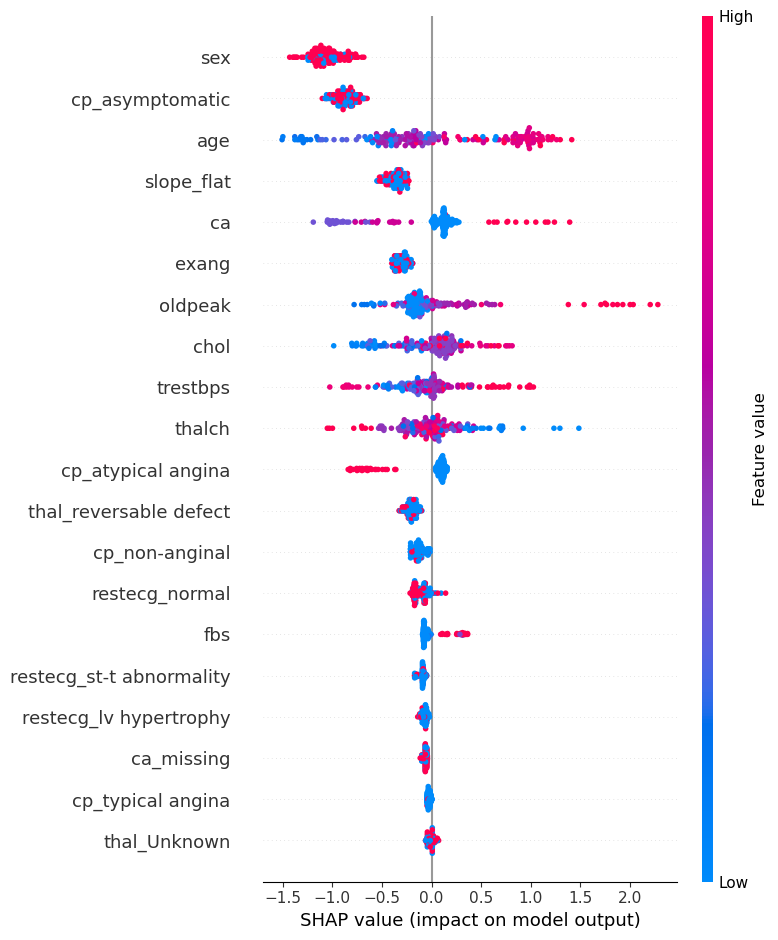

In [172]:
plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    X_test_df,
    show=False
)

plt.tight_layout()
plt.show()

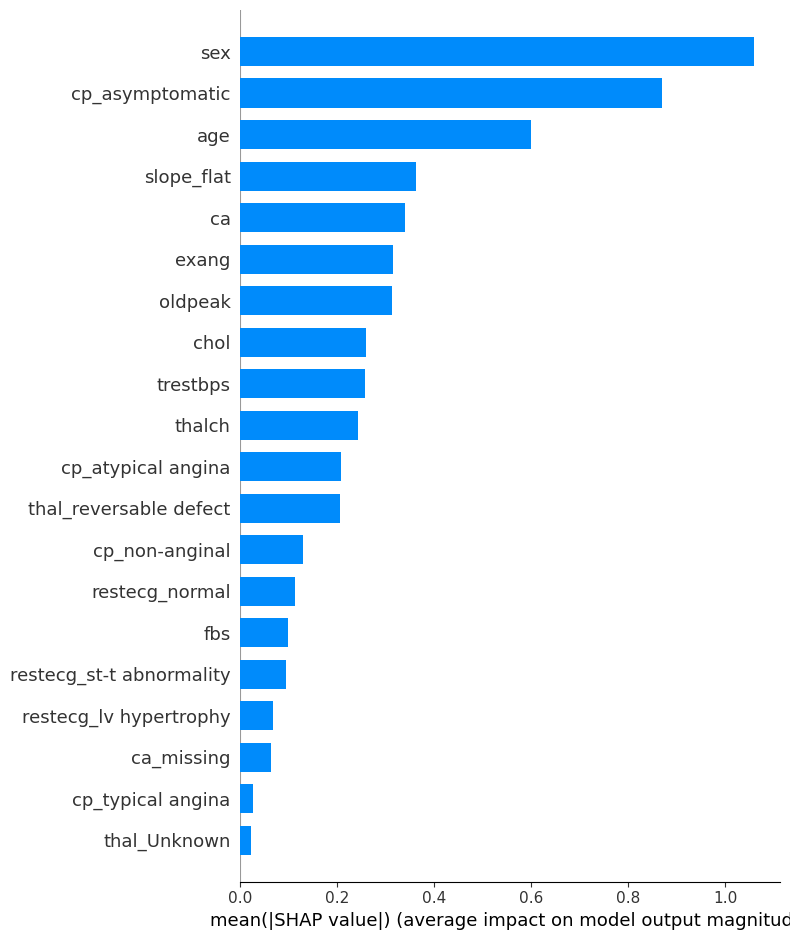

In [173]:
plt.figure(figsize=(10,7))

shap.summary_plot(
    shap_values,
    X_test_df,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.show()

In [174]:
importance = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    "Feature": X_test_df.columns,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

                     Feature  Importance
1                        sex    1.059404
14           cp_asymptomatic    0.869644
0                        age    0.599858
12                slope_flat    0.361137
8                         ca    0.339477
6                      exang    0.314894
7                    oldpeak    0.311628
3                       chol    0.259120
2                   trestbps    0.256829
5                     thalch    0.241627
15        cp_atypical angina    0.206543
24    thal_reversable defect    0.204732
16            cp_non-anginal    0.128671
19            restecg_normal    0.111841
4                        fbs    0.099047
20  restecg_st-t abnormality    0.094197
18    restecg_lv hypertrophy    0.067884
9                 ca_missing    0.063990
17         cp_typical angina    0.025479
21              thal_Unknown    0.021704
22         thal_fixed defect    0.021378
10             slope_Unknown    0.019301
23               thal_normal    0.019188
13           slo

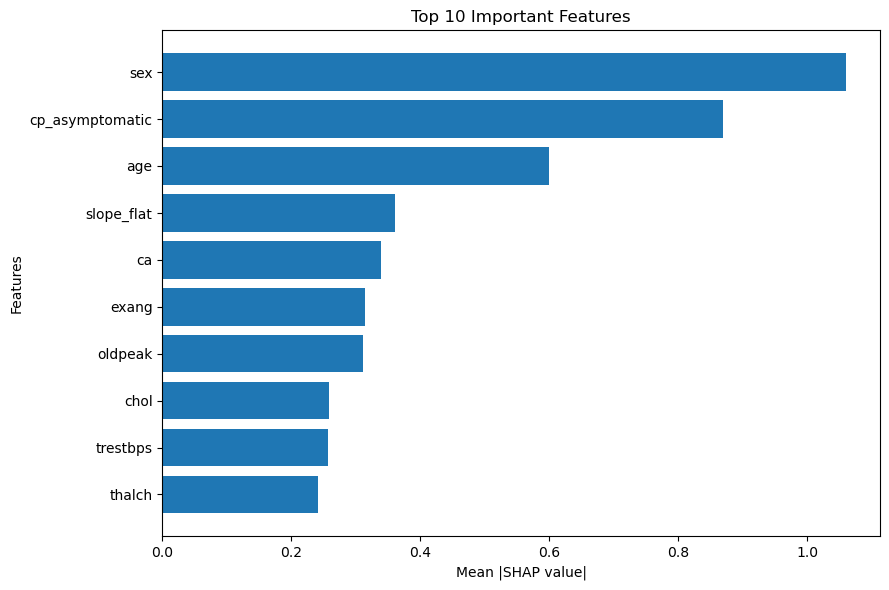

In [175]:
top10 = importance_df.head(10)

plt.figure(figsize=(9,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Features")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

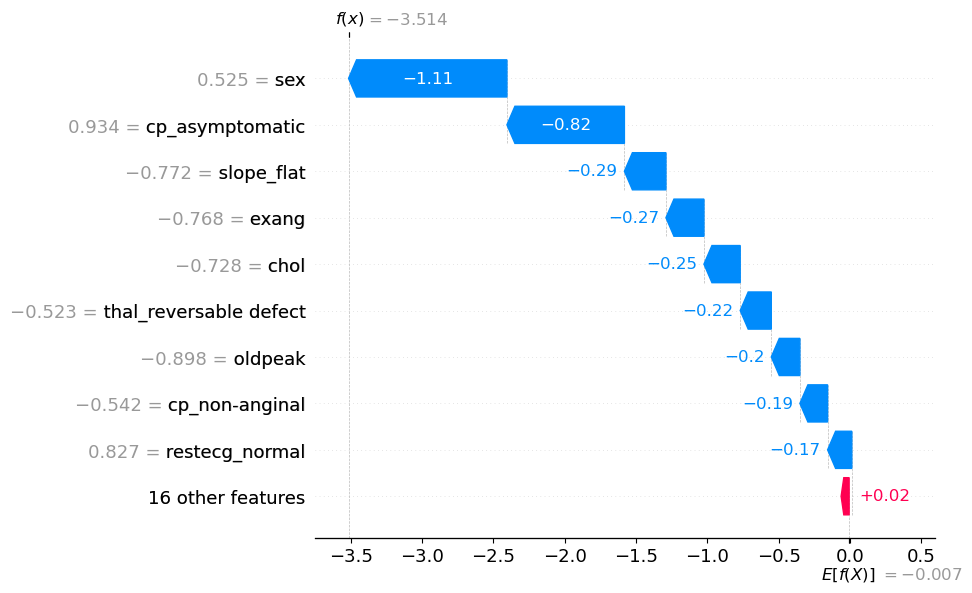

In [176]:
shap.plots.waterfall(
    explainer(X_test_df)[0]
)